# Boosting

## 1. Loading CTR data

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import xgboost as xgb
import time
from IPython.display import display, clear_output

# Sklearn imports
from sklearn.model_selection import train_test_split, GridSearchCV, KFold, ParameterGrid
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error


#################################
# Helper Functions
#################################

def osr2(y_true, y_pred, baseline_mean):
    """
    Calculates the out-of-sample R-squared.

    Args:
        y_true (pd.Series): The true target values.
        y_pred (np.array): The predicted values.
        baseline_mean (float): The mean of the training set's target variable.
    """
    sst = np.sum((y_true - baseline_mean) ** 2)
    sse = np.sum((y_pred - y_true) ** 2)
    if sst == 0: # Avoid division by zero
        return -np.inf if sse > 0 else 1.0
    return 1 - sse / sst

def show_head_tail(df, n=3, m=3):
    """
    Displays the head and tail of a DataFrame separated by an ellipsis.
    """
    if not isinstance(df, pd.DataFrame):
        print("Input must be a pandas DataFrame.")
        return

    # Create a separator DataFrame filled with '...'
    separator = pd.DataFrame([['...'] * len(df.columns)],
                             columns=df.columns,
                             index=['...'])

    # Concatenate the head, separator, and tail
    combined_df = pd.concat([df.head(n), separator, df.tail(m)])

    display(combined_df)

# Note: The other helper functions (significance_stars, print_summary_with_stars)
# were not needed for this specific translation but are available.

#################################
# Data Loading and Splitting
#################################


dat = pd.read_csv("CTR.csv")

X = dat.drop('CTR', axis=1)
y = dat['CTR']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=144 # Same split as previous Lecture
)

# Handle potential categorical variables for models that need dummies
# (like XGBoost and statsmodels)
X_train_dummy = pd.get_dummies(X_train, drop_first=True)
X_test_dummy = pd.get_dummies(X_test, drop_first=True)
# Align columns
X_test_dummy = X_test_dummy.reindex(columns=X_train_dummy.columns, fill_value=0)


### Display

df_train = pd.concat([X_train, y_train], axis=1).sort_index()
df_test = pd.concat([X_test, y_test], axis=1).sort_index()
full_disp = pd.concat([df_train, df_test]).sort_index()

print("Displaying full_disp (16 head, 5 tail):")
show_head_tail(full_disp, 10, 5)

print("Displaying df_train (16 head, 5 tail):")
show_head_tail(df_train, 10, 5)

print("Displaying df_test (16 head, 5 tail):")
show_head_tail(df_test, 10, 5)

print("Displaying full_disp (cols 0, 1, 10):")
show_head_tail(full_disp.iloc[:, [0, 1, 10]], 12, 3)

print("Displaying df_train (cols 0, 1, 10):")
show_head_tail(df_train.iloc[:, [0, 1, 10]], 7, 2)

print("Displaying df_test (cols 0, 1, 10):")
show_head_tail(df_test.iloc[:, [0, 1, 10]], 5, 1)

Displaying full_disp (16 head, 5 tail):


,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender,age,CTR
0,10,17,3,2,0.0136,0.0146,0.0,0.0,male,41+,0.0
1,13,30,2,1,0.0373,0.0465,0.0382,0.0581,male,13-18,0.0761
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
3,5,19,3,2,0.0178,0.0076,0.0035,0.0017,female,25-30,0.0
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
5,15,28,2,2,0.0307,0.0157,0.0324,0.0137,female,31-40,0.0
6,10,20,3,1,0.0283,0.0338,0.0219,0.0353,female,13-18,0.0383
7,9,23,3,1,0.0054,0.0084,0.0183,0.0208,male,25-30,0.0172
8,8,20,2,1,0.0153,0.0282,0.0281,0.0562,male,13-18,0.1015
9,11,21,2,1,0.018,0.0314,0.0216,0.0296,female,13-18,0.0125


Displaying df_train (16 head, 5 tail):


,titleWords,adWords,depth,position,advCTR,advCTRInPos,queryCTR,queryCTRInPos,gender,age,CTR
2,12,14,1,1,0.0254,0.031,0.0255,0.0323,male,13-18,0.0426
3,5,19,3,2,0.0178,0.0076,0.0035,0.0017,female,25-30,0.0
4,11,17,2,2,0.0096,0.0069,0.0294,0.0171,female,19-24,0.0068
5,15,28,2,2,0.0307,0.0157,0.0324,0.0137,female,31-40,0.0
6,10,20,3,1,0.0283,0.0338,0.0219,0.0353,female,13-18,0.0383
7,9,23,3,1,0.0054,0.0084,0.0183,0.0208,male,25-30,0.0172
9,11,21,2,1,0.018,0.0314,0.0216,0.0296,female,13-18,0.0125
10,11,23,2,1,0.1546,0.2058,0.0428,0.0604,unknown,unknown,0.2949
11,9,23,3,2,0.0427,0.0308,0.0593,0.0176,male,31-40,0.0128
12,9,27,1,1,0.035,0.0427,0.0036,0.0041,male,25-30,0.0


Displaying df_test (16 head, 5 tail):


...

,titleWords,adWords,CTR
0,10,17,0.0
1,13,30,0.0761
2,12,14,0.0426
3,5,19,0.0
4,11,17,0.0068
5,15,28,0.0
6,10,20,0.0383
7,9,23,0.0172
8,8,20,0.1015
9,11,21,0.0125


Displaying df_train (cols 0, 1, 10):


,titleWords,adWords,CTR
2,12,14,0.0426
3,5,19,0.0
4,11,17,0.0068
5,15,28,0.0
6,10,20,0.0383
7,9,23,0.0172
9,11,21,0.0125
...,...,...,...
6052,8,16,0.0182
6054,9,26,0.0141


Displaying df_test (cols 0, 1, 10):


,titleWords,adWords,CTR
0,10,17,0.0
1,13,30,0.0761
8,8,20,0.1015
14,9,23,0.025
19,12,27,0.0
...,...,...,...
6056,12,23,0.1322


# 2. Boosting on CTR data

In [3]:
###################
# Boosting
###################

# R: mod.boost1 = gbm(CTR ~ .,
#                  data = df.train,
#                  distribution = "gaussian",
#                  n.trees = 10000,
#                  shrinkage = .01,
#                  interaction.depth = 9, bag.fraction=1)

# We need to use the dummy-encoded X_train for sklearn's GBM
mod_boost1 = GradientBoostingRegressor(
    loss='squared_error',     # R 'distribution = "gaussian"'
    n_estimators = 5000,   # R 'n.trees'
    learning_rate = 0.001,     # R 'shrinkage'
    max_depth = 6,            # R 'interaction.depth'
    subsample = 1.0,          # R 'bag.fraction'
    random_state = 123        # For reproducibility
)

# Sklearn's GBM cannot handle string/object columns directly
boostmodel = mod_boost1.fit(X_train_dummy, y_train)
print("Fitted basic GradientBoostingRegressor (mod_boost1).")

Fitted basic GradientBoostingRegressor (mod_boost1).


In [4]:
pred_boost = boostmodel.predict(X_test_dummy)
osr2_boost = osr2(y_test, pred_boost, y_train.mean())
print(f"Out-of-Sample OSR^2 (from boostmodel): {osr2_boost:.4f}")

Out-of-Sample OSR^2 (from boostmodel): 0.4377


## 3.1. Cross-validation

In [5]:
# # Only run if you want to use dask (uncomment cell)
# !pip install "dask[distributed]"

In [ ]:
# # Only run if you want to use dask (uncomment cell)

# import joblib
# from dask.distributed import Client

# # Set up a dask "client" (this manages the workers)
# # processes=False is often faster for sklearn, as it avoids data transfer
# client = Client(processes=False, n_workers=4, threads_per_worker=1)
# print(f"Dask dashboard link: {client.dashboard_link}")

Dask dashboard link: http://192.168.1.93:56471/status


/Users/pengsun/opt/anaconda3/lib/python3.8/site-packages/distributed/node.py:151: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 56471 instead
  warnings.warn(


--- Starting Boosted Trees GridSearchCV ---
Starting GridSearchCV... (Check your Dask dashboard!)
GridSearchCV took 1136.689621925354 seconds

--- Generating CV Results Plot ---


<ipython-input-11-59f3c0668bdf>:71: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  plot_data['param_max_depth'] = plot_data['param_max_depth'].astype('category')


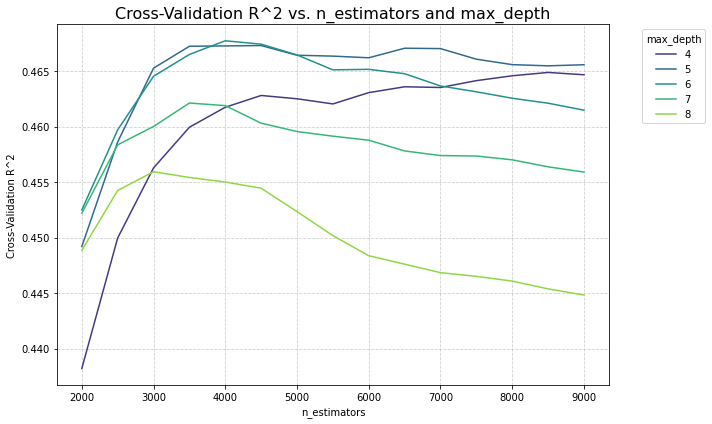


--- Final Model Performance ---
Best parameters found:
{'learning_rate': 0.001, 'max_depth': 6, 'min_samples_leaf': 10, 'n_estimators': 4000}

--- Final Results Table ---
-------------------------------------------------
Parameter tuning took: 1136.689621925354 seconds
-------------------------------------------------
Out-of-Sample OSR^2:   0.4718
Out-of-Sample MAE:     0.0307
Out-of-Sample RMSE:    0.0515
-------------------------------------------------


In [11]:
print("--- Starting Boosted Trees GridSearchCV ---")
np.random.seed(232)

tGrid = {
    'n_estimators': np.arange(2000, 9001, 500),
    'max_depth': np.arange(4, 9),
    'learning_rate': [0.001],
    'min_samples_leaf': [10]
}

# tGrid = {
#     'n_estimators': [100, 1000, 5000, 10000, 15000, 20000, 25000, 30000],
#     'max_depth': [4, 6, 8, 10],
#     'learning_rate': [0.001],
#     'min_samples_leaf': [10]
# } ### TEST RUN

# cv_5_fold = KFold(n_splits=5, shuffle=True, random_state=232)

cv_2_fold = KFold(n_splits=2, shuffle=True, random_state=232) ### TEST RUN

gbr = GradientBoostingRegressor(
    loss='squared_error', # R 'distribution = "gaussian"'
    subsample=1.0,
    random_state=232
)

# --- Tell GridSearchCV to score both RMSE and R^2 ---
# We'll tune (refit) based on neg_mean_squared_error (for RMSE)
# but also calculate 'r2' at each step so we can plot it.
train_boost = GridSearchCV(
    estimator=gbr,
    param_grid=tGrid,
    cv=cv_2_fold,
    scoring=['neg_mean_squared_error', 'r2'], # <--- Calculate both RMSE and R^2
    refit='neg_mean_squared_error',          # <--- Tune based on RMSE
    verbose=0,
    n_jobs=-1 # Use all cores
)

print("Starting GridSearchCV... (Check your Dask dashboard!)")
start_time = time.time()

# This will now show progress in the Dask dashboard

train_boost.fit(X_train_dummy, y_train)

# Only run if you want to use dask (uncomment two lines below and comment line above)
# with joblib.parallel_backend('dask'):
#     train_boost.fit(X_train_dummy, y_train)

end_time = time.time()
total_time_seconds = end_time - start_time
print(f"GridSearchCV took {total_time_seconds} seconds")


# --- 3. Plot Cross-Validation Results ---
print("\n--- Generating CV Results Plot ---")

# Convert the CV results into a pandas DataFrame for easy plotting
cv_results_df = pd.DataFrame(train_boost.cv_results_)

# Extract the columns we need
plot_data = cv_results_df[[
    'param_n_estimators',
    'param_max_depth',
    'mean_test_r2'
]]

# Ensure max_depth is treated as a category for the legend
plot_data['param_max_depth'] = plot_data['param_max_depth'].astype('category')

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=plot_data,
    x='param_n_estimators',
    y='mean_test_r2',
    hue='param_max_depth',
    palette='viridis', # Using a common palette
    legend='full'
)
plt.title('Cross-Validation R^2 vs. n_estimators and max_depth', fontsize=16)
plt.xlabel('n_estimators')
plt.ylabel('Cross-Validation R^2')
plt.legend(title='max_depth', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


# --- 4. Get Final Metrics from BEST Model ---
print("\n--- Final Model Performance ---")

# --- Use the *best model from the grid search ---
# Instead of a hardcoded model, we use the one GridSearchCV found
best_model = train_boost.best_estimator_

print("Best parameters found:")
print(train_boost.best_params_)

# Use the best model to predict on the test set
pred_boost = best_model.predict(X_test_dummy)

# Calculate the final metrics
mae_boost = mean_absolute_error(y_test, pred_boost)
rmse_boost = np.sqrt(mean_squared_error(y_test, pred_boost))
osr2_boost = osr2(y_test, pred_boost, y_train.mean())

# --- 5. Print All Requested Outputs ---
print("\n--- Final Results Table ---")
print("-------------------------------------------------")
print(f"Parameter tuning took: {total_time_seconds} seconds")
print("-------------------------------------------------")
print(f"Out-of-Sample OSR^2:   {osr2_boost:.4f}")
print(f"Out-of-Sample MAE:     {mae_boost:.4f}")
print(f"Out-of-Sample RMSE:    {rmse_boost:.4f}")
print("-------------------------------------------------")

## 3.2. XGBoost

In [8]:
###############
# XGBoost
#(eXtreme Gradient Boosting)
###############

tg_params = {
    'max_depth': [4, 6, 8, 10],
    'eta': [0.001, 0.002],
    'subsample': [0.5],
    'min_child_weight': [1],
    'gamma': [0, 0.02, 0.04],
    'colsample_bytree': [1],
    'alpha': [0.5, 1],
    'lambda': [0]
}
tg = list(ParameterGrid(tg_params))

round_best = np.zeros(len(tg))
rmse_cv = np.zeros(len(tg))
np.random.seed(250)

# Create DMatrix
dtrain = xgb.DMatrix(X_train_dummy, label=y_train)

print(f"Starting manual XGB.cv loop for {len(tg)} combinations...")
# --- Timer starts here ---
start_time = time.time()
for i, params in enumerate(tg):
    cv_results = xgb.cv(
        params=params,
        dtrain=dtrain,
        nfold=2,
        num_boost_round=15000,
        metrics={'rmse'},
        seed=250, # xgb.cv seed
        verbose_eval=False
    )

    best_round_idx = cv_results['test-rmse-mean'].idxmin()
    round_best[i] = best_round_idx + 1 # Store n_rounds
    rmse_cv[i] = cv_results['test-rmse-mean'][best_round_idx]

    if (i+1) % 10 == 0:
        print(f"Iteration {i+1}/{len(tg)} complete.")

# --- Timer ends here ---
print(f"XGB.cv loop took {time.time() - start_time:.2f} seconds")

# --- Get the results from loop ---
winner_idx = np.argmin(rmse_cv)
params_winner = tg[winner_idx]
round_winner = int(round_best[winner_idx])

# Add the seed for the final model build
params_winner['seed'] = 1988

print(f"Winner is index {winner_idx}:")
print(f"Params: {params_winner}")
print(f"Best round: {round_winner}")

# --- Train the final model using the WINNING params ---
mod_xgboost = xgb.train(
    params=params_winner,
    dtrain=dtrain,
    num_boost_round=round_winner,
    verbose_eval=False
)

dtest = xgb.DMatrix(X_test_dummy)
pred_xgboost = mod_xgboost.predict(dtest, iteration_range=(0, round_winner))

# --- Calculate final metrics ---
osr2_xgboost = osr2(y_test, pred_xgboost, y_train.mean())
print(f"XGBoost OSR2: {osr2_xgboost:.7f}")

rmse_xgboost = np.sqrt(mean_squared_error(y_test, pred_xgboost))
print(f"XGBoost RMSE: {rmse_xgboost:.7f}")

mae_xgboost = mean_absolute_error(y_test, pred_xgboost)
print(f"XGBoost MAE: {mae_xgboost:.7f}")

Starting manual XGB.cv loop for 48 combinations...
Iteration 10/48 complete.
Iteration 20/48 complete.
Iteration 30/48 complete.
Iteration 40/48 complete.
XGB.cv loop took 1291.12 seconds
Winner is index 12:
Params: {'alpha': 0.5, 'colsample_bytree': 1, 'eta': 0.002, 'gamma': 0, 'lambda': 0, 'max_depth': 4, 'min_child_weight': 1, 'subsample': 0.5, 'seed': 1988}
Best round: 9763
XGBoost OSR2: 0.4929959
XGBoost RMSE: 0.0504896
XGBoost MAE: 0.0303866
